# Commonsense QA with Chain-of-Thought

## 1. Overview

This notebook builds a complete evaluation pipeline for Commonsense Question Answering using LLMs + Chain-of-Thought (CoT) prompting.

It includes:

*   Baseline prompting
*   Zero-shot CoT prompting
*   Few-shot CoT prompting
*   RE (Rephrase-and-Expand) prompting
*   RE+ prompting
*   Plan-and-Solve (PS) prompting
*   Plan-and-Solve+ prompting
*   Tree-of-Thought (ToT) prompting
*   Self-consistency


In [ ]:
!pip install torch==2.6.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q

## 2. Imports

In [2]:
import re
import torch
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from collections import Counter
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("GPU Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())
print("Current GPU:", torch.cuda.current_device())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

## 3. Load dataset

### Dataset Overview: CommonsenseQA (`tau/commonsense_qa`)

In this Notebook, we use the **CommonsenseQA** dataset, available through the Hugging Face Hub under the identifier **`tau/commonsense_qa`**, as one of the benchmark datasets for evaluating the reasoning and comprehension abilities of large language models (LLMs).

CommonsenseQA is a multiple-choice question answering benchmark specifically designed to test **commonsense reasoning** in natural language understanding systems. Unlike factual question answering tasks, this dataset focuses on whether models can infer everyday knowledge and implicit relationships that humans naturally understand.

The dataset is widely used in artificial intelligence research to assess a model’s ability to perform reasoning beyond memorization, making it particularly relevant for experiments involving **advanced prompting strategies**, **in-context learning**, and **thinking models**.

##### Dataset Description

CommonsenseQA was introduced by researchers at **Tel Aviv University** and is constructed using concepts derived from **ConceptNet**, a large semantic knowledge graph.

Each example in the dataset contains:

- A **natural language question**
- **Five answer choices**
- One **correct answer label**

The questions are designed to require reasoning about everyday situations, object properties, social interactions, and practical knowledge.

##### Example Structure

```json
{
  "id": "075e483d21c29a511267ef62bedc0461",
  "question": "Where would you find magazines along side many other printed works?",
  "question_concept": "magazines",
  "choices": {
    "label": ["A", "B", "C", "D", "E"],
    "text": [
      "doctor",
      "bookstore",
      "market",
      "train station",
      "mortuary"
    ]
  },
  "answerKey": "B"
}

In [ ]:
# CommonsenseQA dataset
dataset = load_dataset("tau/commonsense_qa")

# Use validation split for quick evaluation
samples = dataset["validation"].select(range(10))

## 4. Load model

### Model Overview: DeepSeek-R1-Distill-Qwen-7B (`deepseek-ai/DeepSeek-R1-Distill-Qwen-7B`)

In this Notebook, we employ **DeepSeek-R1-Distill-Qwen-7B**, available on the Hugging Face Hub under the identifier **`deepseek-ai/DeepSeek-R1-Distill-Qwen-7B`**, as one of the core large language models (LLMs) for benchmarking reasoning performance under advanced prompting strategies.

This model belongs to the **reasoning-oriented family of distilled language models**, designed to preserve strong logical inference capabilities while remaining computationally efficient. It is derived from the **DeepSeek-R1** reasoning framework and distilled into a **7-billion-parameter architecture** based on the **Qwen** model family.

The model is particularly relevant for experiments focused on **Chain-of-Thought prompting**, **structured reasoning**, and **thinking-model evaluation**, as it is optimized for deliberate and stepwise problem-solving.


#### Model Description

DeepSeek-R1-Distill-Qwen-7B is a **causal language model** developed by :contentReference[oaicite:0]{index=0} and released as part of the DeepSeek-R1 series.

Its objective is to provide high-quality reasoning performance in a smaller and more accessible architecture through **knowledge distillation**. Distillation transfers reasoning patterns from larger teacher models into compact student models, enabling efficient deployment while maintaining competitive capabilities.

This version uses the **Qwen-based 7B backbone**, offering a balance between:

- **Reasoning strength**
- **Inference speed**
- **Hardware accessibility**

The model is especially suited for research environments where computational resources are limited but advanced reasoning evaluation remains essential.


In [ ]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
model_path= "/kaggle/input/models/deepseek-ai/deepseek-r1/transformers/deepseek-r1-distill-qwen-7b/2"
#Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

#Load model
model = AutoModelForCausalLM.from_pretrained(
   model_path,
   dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
   device_map="auto"
)

## 5. Helper functions

In [ ]:
def format_question(sample):
    question = sample["question"]
    choices = sample["choices"]

    options = "\n".join([
        f"{label}: {text}"
        for label, text in zip(choices["label"], choices["text"])
    ])

    return f"Question: {question}\nChoices:\n{options}"

In [ ]:
def generate_response(prompt, max_new_tokens=4080, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]  # number of prompt tokens
    
    start_time = time.time()
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature
    )
    end_time = time.time()
    duration = (end_time - start_time) / 60

    # Slice off the prompt tokens, decode only the new generated tokens
    new_tokens = outputs[0][input_length:]
    generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True)

    generated_tokens_count = len(tokenizer.encode(generated_text, add_special_tokens=False))
    return generated_text, duration, generated_tokens_count

In [ ]:
def extract_answer(text):
    # Strip logging lines like "Extracted RE+ Answer: A", "Extracted Baseline Answer: B", etc.
    text = re.sub(r"\nExtracted\b.*?Answer:.*$", "", text, flags=re.IGNORECASE | re.MULTILINE)

    # Core building blocks
    L = r"\**\s*\(?([A-Ea-e])\)?\s*\**"
    S = r"\s*:?\s*\**\s*"
    # P1 — Final Answer (highest priority)
    for p in [
        rf"[Ff]inal\s+[Aa]nswer{S}{L}",
        rf"[Mm]y\s+final\s+answer\s+is{S}{L}",
    ]:
        m = re.findall(p, text)
        if m: return m[-1].upper()

    # P2 — "The answer is / correct answer/option/choice is / therefore..."
    for p in [
        rf"[Tt]he\s+(?:correct\s+)?(?:answer|option|choice|response)\s+is{S}{L}",
        rf"[Tt]he\s+best\s+answer\s+is{S}{L}",
        rf"(?:[Tt]herefore|[Tt]hus|[Hh]ence|[Ss]o)[,\s]+(?:the\s+)?answer\s+is{S}{L}",
        rf"[Tt]herefore[,\s]+{L}\s+is\s+correct",
        rf"[Ii]\s+(?:think|believe|would\s+say)\s+(?:the\s+)?answer\s+is{S}{L}",
        rf"[Tt]his\s+means\s+the\s+answer\s+is{S}{L}",
    ]:
        m = re.findall(p, text)
        if m: return m[-1].upper()

    # P3 — "I choose/select/pick X"
    m = re.findall(rf"[Ii]\s+(?:choose|select|pick){S}{L}", text)
    if m: return m[-1].upper()

    # P4 — "Answer: X" label (X must NOT be followed by alpha → avoids "Answer: A word")
    m = re.findall(rf"(?i)\banswer\s*:\s*\**\s*\(?([A-Ea-e])\)?(?![a-zA-Z])", text)
    if m: return m[-1].upper()

    # P5 — "Option/Choice X is correct" or "Option X"
    for p in [
        rf"(?:[Oo]ption|[Cc]hoice)\s+{L}\s+is\s+(?:correct|the\s+answer)",
        rf"(?:[Oo]ption|[Cc]hoice){S}{L}(?![a-zA-Z])",
    ]:
        m = re.findall(p, text)
        if m: return m[-1].upper()

    # P6 — Bold "**X:**" e.g. "**C: department store**"
    m = re.findall(r"\*\*([A-Ea-e])\s*[:\)]", text)
    if m: return m[-1].upper()

    # P7 — Standalone "(X)"
    m = re.findall(r"\(([A-Ea-e])\)", text)
    if m: return m[-1].upper()

    # P8 — "X: word" or "X) word" at start of line
    m = re.findall(r"(?:^|\n)\s*([A-E])[:\)\.]\s+\w", text)
    if m: return m[-1].upper()

    # Last resort — last standalone uppercase A–E in text
    m = re.findall(r"\b([A-E])\b", text)
    return m[-1] if m else None

## 6. Prompt templates

### 6.1. Standard Prompting

Feeds the question directly to the model with no special reasoning instructions. The model produces a response in a single pass. Used as the baseline to compare all other strategies against.

**`0-shot`** **`limited reasoning`** **`fast`**


In [ ]:
def baseline_prompt(sample):
    return f"""
Answer the following multiple-choice question.
Give only the correct option letter.

{format_question(sample)}

Answer:
"""


### 6.2. Zero-shot Chain-of-Thought (CoT)

Adds the instruction "Think step by step" without providing any examples. The model spontaneously generates intermediate reasoning before answering. 

**`0-shot`** **`explicit reasoning`** **`variable quality`**


In [ ]:
def zeroshot_cot_prompt(sample):
    return f"""
Think step by step before answering.
Then provide the final option letter.

{format_question(sample)}

Reasoning:
"""

### 6.3. Few-shot Chain-of-Thought

Provides complete examples (question + reasoning + answer) in the prompt. The model learns the expected reasoning format by imitation.

**`few-shot`** **`guided reasoning`** **`tokens ↑`**


In [ ]:
FEW_SHOT_EXAMPLES = [
    {
        "question": "If 2x + 3 = 11, what is x?\nA) 3  B) 4  C) 5  D) 6",
        "reasoning": "2x = 11 - 3 = 8, so x = 4.",
        "answer": "B"
    },
    {
        "question": "What is the capital of France?\nA) Berlin  B) Rome  C) Paris  D) Madrid",
        "reasoning": "France is a country in Western Europe. Its capital is Paris.",
        "answer": "C"
    },
]
def fewshot_cot_prompt(sample, examples=FEW_SHOT_EXAMPLES):
    shots = ""
    for ex in examples:
        shots += f"""
            Q: {ex['question']}
            Reasoning: {ex['reasoning']}
            Answer: {ex['answer']}
            """
    return f"""
Here are some examples:                                                                                                                                                                                                                                                                                                                                                                        
{shots}
Now answer the following question step by step.

{format_question(sample)}

Reasoning:
"""

### 6.4. RE (Rephrase-and-Expand) / RE+

Asks the model to rephrase and expand the question before reasoning (RE). The RE+ variant adds a verification step after reasoning. Reduces errors caused by misunderstood or ambiguous questions.

**`rephrasing`** **`better comprehension`**


In [ ]:
def re_prompt(sample):
    return f"""
First, rephrase and expand the following question in your own
words to make sure you understand it correctly.
Then reason step by step and give the final answer letter.

{format_question(sample)}

Rephrased question:
"""

In [ ]:
def re_plus_prompt(sample):
    return f"""
Step 1 — Rephrase the question in your own words.
Step 2 — Reason step by step.
Step 3 — Verify: re-read your reasoning and check for errors.
Step 4 — Give the final answer letter.

{format_question(sample)}

Step 1 — Rephrased:
"""

### 6.5. Self-consistency

Generates multiple independent reasoning paths (temperature > 0) then selects the answer by majority vote. Improves robustness without changing the prompt, at the cost of N × inference calls.

**`majority vote`** **`robustness ↑`** **`cost × N`**


In [ ]:
def self_consistency(sample, n=5):
    answers = []
    total_duration = 0.0
    total_tokens = 0

    for i in range(n):
        # Assuming generate_response returns (text, duration, tokens_count)
        output_text, duration, tokens_count = generate_response(zeroshot_cot_prompt(sample), temperature=0.8)
        ans = extract_answer(output_text)
        
        total_duration += duration
        total_tokens += tokens_count
        
        if ans:
            answers.append(ans)
            print(f"Iteration {i+1}: Extracted Answer = {ans}, Duration = {duration:.2f} minutes, Tokens = {tokens_count}")
        else:
            print(f"Iteration {i+1}: No Answer Extracted, Duration = {duration:.2f} minutes, Tokens = {tokens_count}")

    if not answers:
        return None, None, total_duration, total_tokens # Return totals even if no answers

    vote_counts = Counter(answers)
    most_common_answer = vote_counts.most_common(1)[0][0]
    
    print(f"\nTotal Self-Consistency Duration: {total_duration:.2f} seconds")
    print(f"Total Self-Consistency Generated Tokens: {total_tokens}")
    
    return most_common_answer, vote_counts, total_duration, total_tokens

### 6.6. Plan-and-Solve (PS / PS+)

Asks the model to first devise a plan, then execute each step. PS+ adds precision instructions ("extract relevant variables", "calculate step by step"). Reduces arithmetic and logic errors.

**`0-shot`** **`planning`** **`fewer arith. errors`**


In [ ]:
def plan_and_solve_prompt(sample):
    """
    Plan-and-Solve — Wang et al. (2023).
    Encourage la planification explicite avant l'exécution.
    Variante PS : plan simple.
    """
    return f"""
Let's first understand the problem and devise a plan to solve it.
Then, let's carry out the plan and solve the problem step by step.

{format_question(sample)}

Plan:
"""

In [ ]:
def plan_and_solve_plus_prompt(sample):
    """
    Plan-and-Solve+ — variante avec instructions de précision.
    Ajoute des consignes pour extraire les variables pertinentes
    et calculer avec soin avant de conclure.
    """
    return f"""
Let's first understand the problem, extract relevant variables
and their corresponding numerals, and devise a complete plan.
Then, let's carry out the plan step by step, calculate
carefully and verify each step.

{format_question(sample)}

Plan:
"""

## 7. Demonstrate Methods with a Single Example

In [ ]:
# Select the first sample for demonstration
demo_sample = samples[0]
print(f"Question: {demo_sample['question']}")
print(f"Ground Truth Answer: {demo_sample['answerKey']}\n")

### 7.1. Baseline Method Demonstration

In [ ]:
# Baseline Prompt
baseline_p = baseline_prompt(demo_sample)

In [ ]:
# generate Baseline Response
baseline_response_text, baseline_duration, baseline_tokens_count = generate_response(baseline_p)

In [ ]:
# extract Baseline Response
baseline_extracted_answer = extract_answer(baseline_response_text)

In [ ]:
# Prepare data for baseline method for the demo_sample
method_name = "Baseline"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": baseline_p,
    "generated_response_text": baseline_response_text,
    "extracted_answer": baseline_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": baseline_duration,
    "generated_tokens_count": baseline_tokens_count
}

# Save to a JSON file
file_name = "demo_baseline_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for baseline method saved to {file_name}")

In [ ]:
# # Read the JSON file
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_baseline_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# baseline_p = loaded_results.get("prompt")
# baseline_response_text = loaded_results.get("generated_response_text")
# baseline_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# baseline_duration = loaded_results.get("response_duration_minutes")
# baseline_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- Baseline Prompt ---")
print(baseline_p)
print("\n--- Baseline Response ---")
print(baseline_response_text)
print(f"\nExtracted Baseline Answer: {baseline_extracted_answer}")
print(f"Response Duration: {baseline_duration:.2f} minutes")
print(f"Generated Tokens: {baseline_tokens_count}")

### 7.2. Zero-shot Chain-of-Thought (CoT) Method Demonstration

In [ ]:
# Zero-Shot CoT Prompt
zeroshot_cot_p = zeroshot_cot_prompt(demo_sample)

In [ ]:
# generate Zero-Shot CoT Response
zeroshot_cot_response_text, zeroshot_cot_duration, zeroshot_cot_tokens_count = generate_response(zeroshot_cot_p)

In [ ]:
# extract Zero-Shot CoT Response
zeroshot_cot_extracted_answer = extract_answer(zeroshot_cot_response_text)

In [ ]:
# Prepare data for Zero-Shot CoT method for the demo_sample
method_name = "Zero-Shot CoT"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": zeroshot_cot_p,
    "generated_response_text": zeroshot_cot_response_text,
    "extracted_answer": zeroshot_cot_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": zeroshot_cot_duration,
    "generated_tokens_count": zeroshot_cot_tokens_count
}

# Save to a JSON file
file_name = "demo_zeroshot_cot_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for Zero-Shot CoT method saved to {file_name}")

In [ ]:
# # Read the JSON file for Zero-Shot CoT results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_zeroshot_cot_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# zeroshot_cot_p = loaded_results.get("prompt")
# zeroshot_cot_response_text = loaded_results.get("generated_response_text")
# zeroshot_cot_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# zeroshot_cot_duration = loaded_results.get("response_duration_minutes")
# zeroshot_cot_tokens_count = loaded_results.get("generated_tokens_count")


In [ ]:
print("\n--- Zero-Shot CoT Prompt ---")
print(zeroshot_cot_p)
print("\n--- Zero-Shot CoT Response ---")
print(zeroshot_cot_response_text)
print(f"\nExtracted Zero-Shot CoT Answer: {zeroshot_cot_extracted_answer}")
print(f"Response Duration: {zeroshot_cot_duration:.2f} minutes")
print(f"Generated Tokens: {zeroshot_cot_tokens_count}")

### 7.3. Few-shot Chain-of-Thought (CoT) Method Demonstration

In [ ]:
# Few-Shot CoT Prompt
fewshot_cot_p = fewshot_cot_prompt(demo_sample)

In [ ]:
# generate Few-Shot CoT Response
fewshot_cot_response_text, fewshot_cot_duration, fewshot_cot_tokens_count = generate_response(fewshot_cot_p)

In [ ]:
# extract Few-Shot CoT Response
fewshot_cot_extracted_answer = extract_answer(fewshot_cot_response_text)

In [ ]:
# Prepare data for Few-Shot CoT method for the demo_sample
method_name = "Few-Shot CoT"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": fewshot_cot_p,
    "generated_response_text": fewshot_cot_response_text,
    "extracted_answer": fewshot_cot_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": fewshot_cot_duration,
    "generated_tokens_count": fewshot_cot_tokens_count
}

# Save to a JSON file
file_name = "demo_fewshot_cot_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for Few-Shot CoT method saved to {file_name}")

In [ ]:
# # Read the JSON file for Few-Shot CoT results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_fewshot_cot_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# fewshot_cot_p = loaded_results.get("prompt")
# fewshot_cot_response_text = loaded_results.get("generated_response_text")
# fewshot_cot_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# fewshot_cot_duration = loaded_results.get("response_duration_minutes")
# fewshot_cot_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- Few-Shot CoT Prompt ---")
print(fewshot_cot_p)
print("\n--- Few-Shot CoT Response ---")
print(fewshot_cot_response_text)
print(f"\nExtracted Few-Shot CoT Answer: {fewshot_cot_extracted_answer}")
print(f"Response Duration: {fewshot_cot_duration :.2f} minutes")
print(f"Generated Tokens: {fewshot_cot_tokens_count}")

### 7.4. RE (Rephrase-and-Expand) / RE+ Method Demonstration

In [ ]:
# RE Prompt
re_p = re_prompt(demo_sample)

In [ ]:
# generate RE Response
re_response_text, re_duration, re_tokens_count = generate_response(re_p)

In [ ]:
# extract RE Response
re_extracted_answer = extract_answer(re_response_text)

In [ ]:
# Prepare data for RE method for the demo_sample
method_name = "RE"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": re_p,
    "generated_response_text": re_response_text,
    "extracted_answer": re_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": re_duration,
    "generated_tokens_count": re_tokens_count
}

# Save to a JSON file
file_name = "demo_re_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for RE method saved to {file_name}")

In [ ]:
# # Read the JSON file for RE results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_re_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# re_p = loaded_results.get("prompt")
# re_response_text = loaded_results.get("generated_response_text")
# re_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# re_duration = loaded_results.get("response_duration_minutes")
# re_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- RE Prompt ---")
print(re_p)
print("\n--- RE Response ---")
print(re_response_text)
print(f"\nExtracted RE Answer: {re_extracted_answer}")
print(f"Response Duration: {re_duration :.2f} minutes")
print(f"Generated Tokens: {re_tokens_count}")

In [ ]:
# RE+ Prompt
re_plus_p = re_plus_prompt(demo_sample)

In [ ]:
# generate RE+ Response
re_plus_response_text, re_plus_duration, re_plus_tokens_count = generate_response(re_plus_p)

In [ ]:
# extract RE+ Response
re_plus_extracted_answer = extract_answer(re_plus_response_text)

In [ ]:
# Prepare data for RE+ method for the demo_sample
method_name = "RE+"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": re_plus_p,
    "generated_response_text": re_plus_response_text,
    "extracted_answer": re_plus_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": re_plus_duration,
    "generated_tokens_count": re_plus_tokens_count
}

# Save to a JSON file
file_name = "demo_re_plus_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for RE+ method saved to {file_name}")

In [ ]:
# # Read the JSON file for RE+ results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_re_plus_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# re_plus_p = loaded_results.get("prompt")
# re_plus_response_text = loaded_results.get("generated_response_text")
# re_plus_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# re_plus_duration = loaded_results.get("response_duration_minutes")
# re_plus_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- RE+ Prompt ---")
print(re_plus_p)
print("\n--- RE+ Response ---")
print(re_plus_response_text)
print(f"\nExtracted RE+ Answer: {re_plus_extracted_answer}")
print(f"Response Duration: {re_plus_duration:.2f} minutes")
print(f"Generated Tokens: {re_plus_tokens_count}")

### 7.5. Self-Consistency Method Demonstration

In [ ]:
# Self-Consistency Method
sc_final_answer, sc_vote_counts, sc_total_duration, sc_total_tokens = self_consistency(demo_sample, n=5)

In [ ]:
# Prepare data for Self-Consistency method for the demo_sample
method_name = "Self-Consistency"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "zeroshot_cot_prompt_used": zeroshot_cot_p, # Assuming the last zeroshot_cot_p is relevant as base for self-consistency
    "self_consistency_final_answer": sc_final_answer,
    "vote_counts": dict(sc_vote_counts) if sc_vote_counts else {},
    "ground_truth_answer": demo_sample['answerKey'],
    "self_consistency_total_duration_seconds": sc_total_duration,
    "self_consistency_total_generated_tokens": sc_total_tokens
}

# Save to a JSON file
file_name = "demo_self_consistency_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for Self-Consistency method saved to {file_name}")

In [ ]:
# # Read the JSON file for Self-Consistency results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_self_consistency_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# zeroshot_cot_prompt_used = loaded_results.get("zeroshot_cot_prompt_used")
# sc_final_answer = loaded_results.get("self_consistency_final_answer")
# sc_vote_counts = loaded_results.get("vote_counts")
# ground_truth = loaded_results.get("ground_truth_answer")
# sc_total_duration = loaded_results.get("self_consistency_total_duration_seconds")
# sc_total_tokens = loaded_results.get("self_consistency_total_generated_tokens")

In [ ]:
print("\n--- Self-Consistency (n=3) ---")
print(f"Self-Consistency Final Answer: {sc_final_answer}")
print(f"Vote Counts: {sc_vote_counts}")
print(f"Total Duration for Self-Consistency: {sc_total_duration :.2f} minutes")
print(f"Total Tokens Generated for Self-Consistency: {sc_total_tokens}")

### 7.6. Plan-and-Solve (PS / PS+) Method Demonstration

In [ ]:
# Plan-and-Solve Prompt
plan_and_solve_p = plan_and_solve_prompt(demo_sample)


In [ ]:
# generate Plan-and-Solve Response
plan_and_solve_response_text, plan_and_solve_duration, plan_and_solve_tokens_count = generate_response(plan_and_solve_p)


In [ ]:
# extract Plan-and-Solve Response
plan_and_solve_extracted_answer = extract_answer(plan_and_solve_response_text)

In [ ]:
# Prepare data for Plan-and-Solve method for the demo_sample
method_name = "Plan-and-Solve"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": plan_and_solve_p,
    "generated_response_text": plan_and_solve_response_text,
    "extracted_answer": plan_and_solve_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": plan_and_solve_duration,
    "generated_tokens_count": plan_and_solve_tokens_count
}

# Save to a JSON file
file_name = "demo_plan_and_solve_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for Plan-and-Solve method saved to {file_name}")

In [ ]:
# # Read the JSON file for Plan-and-Solve results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_plan_and_solve_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# plan_and_solve_p = loaded_results.get("prompt")
# plan_and_solve_response_text = loaded_results.get("generated_response_text")
# plan_and_solve_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# plan_and_solve_duration = loaded_results.get("response_duration_minutes")
# plan_and_solve_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- Plan-and-Solve Prompt ---")
print(plan_and_solve_p)
print("\n--- Plan-and-Solve Response ---")
print(plan_and_solve_response_text)
print(f"\nExtracted Plan-and-Solve Answer: {plan_and_solve_extracted_answer}")
print(f"Response Duration: {plan_and_solve_duration:.2f} minutes")
print(f"Generated Tokens: {plan_and_solve_tokens_count}")

In [ ]:
# Plan-and-Solve+ Prompt
plan_and_solve_plus_p = plan_and_solve_plus_prompt(demo_sample)


In [ ]:
# generate Plan-and-Solve+ Response
plan_and_solve_plus_response_text, plan_and_solve_plus_duration, plan_and_solve_plus_tokens_count = generate_response(plan_and_solve_plus_p)


In [ ]:
# extract Plan-and-Solve+ Response
plan_and_solve_plus_extracted_answer = extract_answer(plan_and_solve_plus_response_text)

In [ ]:
# Prepare data for Plan-and-Solve+ method for the demo_sample
method_name = "Plan-and-Solve+"
results_to_save = {
    "model_name": model_name,
    "method": method_name,
    "prompt": plan_and_solve_plus_p,
    "generated_response_text": plan_and_solve_plus_response_text,
    "extracted_answer": plan_and_solve_plus_extracted_answer,
    "ground_truth_answer": demo_sample['answerKey'],
    "response_duration_minutes": plan_and_solve_plus_duration,
    "generated_tokens_count": plan_and_solve_plus_tokens_count
}

# Save to a JSON file
file_name = "demo_plan_and_solve_plus_results.json"
with open(file_name, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Results for Plan-and-Solve+ method saved to {file_name}")

In [ ]:
# # Read the JSON file for Plan-and-Solve+ results
# file_name = "/kaggle/input/datasets/zakihanfer/demonstration-files/demo_plan_and_solve_plus_results.json"
# with open(file_name, 'r') as f:
#     loaded_results = json.load(f)

# # Extract variables
# model_name = loaded_results.get("model_name")
# method_name = loaded_results.get("method")
# plan_and_solve_plus_p = loaded_results.get("prompt")
# plan_and_solve_plus_response_text = loaded_results.get("generated_response_text")
# plan_and_solve_plus_extracted_answer = loaded_results.get("extracted_answer")
# ground_truth = loaded_results.get("ground_truth_answer")
# plan_and_solve_plus_duration = loaded_results.get("response_duration_minutes")
# plan_and_solve_plus_tokens_count = loaded_results.get("generated_tokens_count")

In [ ]:
print("\n--- Plan-and-Solve+ Prompt ---")
print(plan_and_solve_plus_p)
print("\n--- Plan-and-Solve+ Response ---")
print(plan_and_solve_plus_response_text)
print(f"\nExtracted Plan-and-Solve+ Answer: {plan_and_solve_plus_extracted_answer}")
print(f"Response Duration: {plan_and_solve_plus_duration:.2f} minutes")
print(f"Generated Tokens: {plan_and_solve_plus_tokens_count}")

## 8. Evaluation

In [ ]:
all_results = []

for i, sample in enumerate(samples):
    print(f"Processing sample {i+1}/{len(samples)}...")
    gt = sample["answerKey"]

    # Baseline
    base_text, base_duration, base_tokens = generate_response(baseline_prompt(sample))
    base_pred = extract_answer(base_text)

    # Zero-shot CoT
    zs_cot_text, zs_cot_duration, zs_cot_tokens = generate_response(zeroshot_cot_prompt(sample))
    zs_cot_pred = extract_answer(zs_cot_text)

    # Few-shot CoT
    # fs_cot_text, fs_cot_duration, fs_cot_tokens = generate_response(fewshot_cot_prompt(sample), max_new_tokens=256)
    # fs_cot_pred = extract_answer(fs_cot_text)

    # RE
    re_text, re_duration, re_tokens = generate_response(re_prompt(sample))
    re_pred = extract_answer(re_text)

    # RE+
    # re_plus_text, re_plus_duration, re_plus_tokens = generate_response(re_plus_prompt(sample), max_new_tokens=256)
    # re_plus_pred = extract_answer(re_plus_text)

    # Plan-and-Solve
    ps_text, ps_duration, ps_tokens = generate_response(plan_and_solve_prompt(sample))
    ps_pred = extract_answer(ps_text)

    # Plan-and-Solve+
    # ps_plus_text, ps_plus_duration, ps_plus_tokens = generate_response(plan_and_solve_plus_prompt(sample), max_new_tokens=256)
    # ps_plus_pred = extract_answer(ps_plus_text)

   

    all_results.append({
        "question": sample["question"],
        "ground_truth": gt,

        "baseline_pred": base_pred,
        "baseline_duration": base_duration,
        "baseline_tokens": base_tokens,

        "zeroshot_cot_pred": zs_cot_pred,
        "zeroshot_cot_duration": zs_cot_duration,
        "zeroshot_cot_tokens": zs_cot_tokens,

        # "fewshot_cot_pred": fs_cot_pred,
        # "fewshot_cot_duration": fs_cot_duration,
        # "fewshot_cot_tokens": fs_cot_tokens,

        "re_pred": re_pred,
        "re_duration": re_duration,
        "re_tokens": re_tokens,

        # "re_plus_pred": re_plus_pred,
        # "re_plus_duration": re_plus_duration,
        # "re_plus_tokens": re_plus_tokens,

        "plan_and_solve_pred": ps_pred,
        "plan_and_solve_duration": ps_duration,
        "plan_and_solve_tokens": ps_tokens,

        # "plan_and_solve_plus_pred": ps_plus_pred,
        # "plan_and_solve_plus_duration": ps_plus_duration,
        # "plan_and_solve_plus_tokens": ps_plus_tokens,

        # "self_consistency_pred": sc_pred,
        # "self_consistency_duration": sc_duration,
        # "self_consistency_tokens": sc_tokens,
        # "self_consistency_vote_counts": dict(sc_vote_counts) if sc_vote_counts else {}
    })


In [ ]:
df_results = pd.DataFrame(all_results)
df_results.to_csv('evaluation_results.csv', index=False)
print("Results saved to evaluation_results.csv")

In [3]:
df_results = pd.read_csv('/kaggle/input/datasets/zakihanfer/evaluation-results/evaluation_results.csv')
print("Evaluation results loaded successfully:")
print(df_results.head())

Evaluation results loaded successfully:
                                            question ground_truth  \
0  A revolving door is convenient for two directi...            A   
1                  What do people aim to do at work?            A   
2  Where would you find magazines along side many...            B   
3         Where are  you likely to find a hamburger?            A   
4  James was looking for a good place to buy farm...            A   

  baseline_pred  baseline_duration  baseline_tokens zeroshot_cot_pred  \
0             C           9.145726             1236                 D   
1             B           1.506286              205                 B   
2             B           1.035133              140                 B   
3             A           0.504893               67                 A   
4             B           0.597724               80                 A   

   zeroshot_cot_duration  zeroshot_cot_tokens re_pred  re_duration  re_tokens  \
0              13.835070 

## 9. Compute Metrics

In [4]:
df = df_results.copy()

strategies = ['baseline', 'zeroshot_cot', 're', 'plan_and_solve']
question_numbers = np.arange(1, len(df) + 1)

In [5]:
metrics = []

for s in strategies:
    pred_col = f"{s}_pred"
    dur_col = f"{s}_duration"
    tok_col = f"{s}_tokens"
    valid_df = df[['ground_truth', pred_col]].dropna()
    accuracy = (valid_df[pred_col] == valid_df['ground_truth']).mean() * 100
    avg_duration = df[dur_col].mean()   # in minutes
    avg_tokens = df[tok_col].mean()

    metrics.append([s, accuracy, avg_duration, avg_tokens])

metrics_df = pd.DataFrame(
    metrics,
    columns=['Strategy', 'Accuracy', 'Avg Duration', 'Avg Tokens']
)

In [6]:
norm_acc = metrics_df["Accuracy"] / metrics_df["Accuracy"].max()
norm_dur = 1 - (metrics_df["Avg Duration"] / metrics_df["Avg Duration"].max())
norm_tok = 1 - (metrics_df["Avg Tokens"] / metrics_df["Avg Tokens"].max())

efficiency_score = (0.5 * norm_acc) + (0.25 * norm_dur) + (0.25 * norm_tok)

metrics_df["Efficiency Score"] = efficiency_score * 100

In [7]:
print(metrics_df)

         Strategy  Accuracy  Avg Duration  Avg Tokens  Efficiency Score
0        baseline      60.0      1.903540       257.4         78.951381
1    zeroshot_cot      50.0      6.840851       926.0         35.714286
2              re      70.0      4.973584       672.9         63.657111
3  plan_and_solve      60.0      6.782876       912.4         43.436185


## 10. Performance Visualization

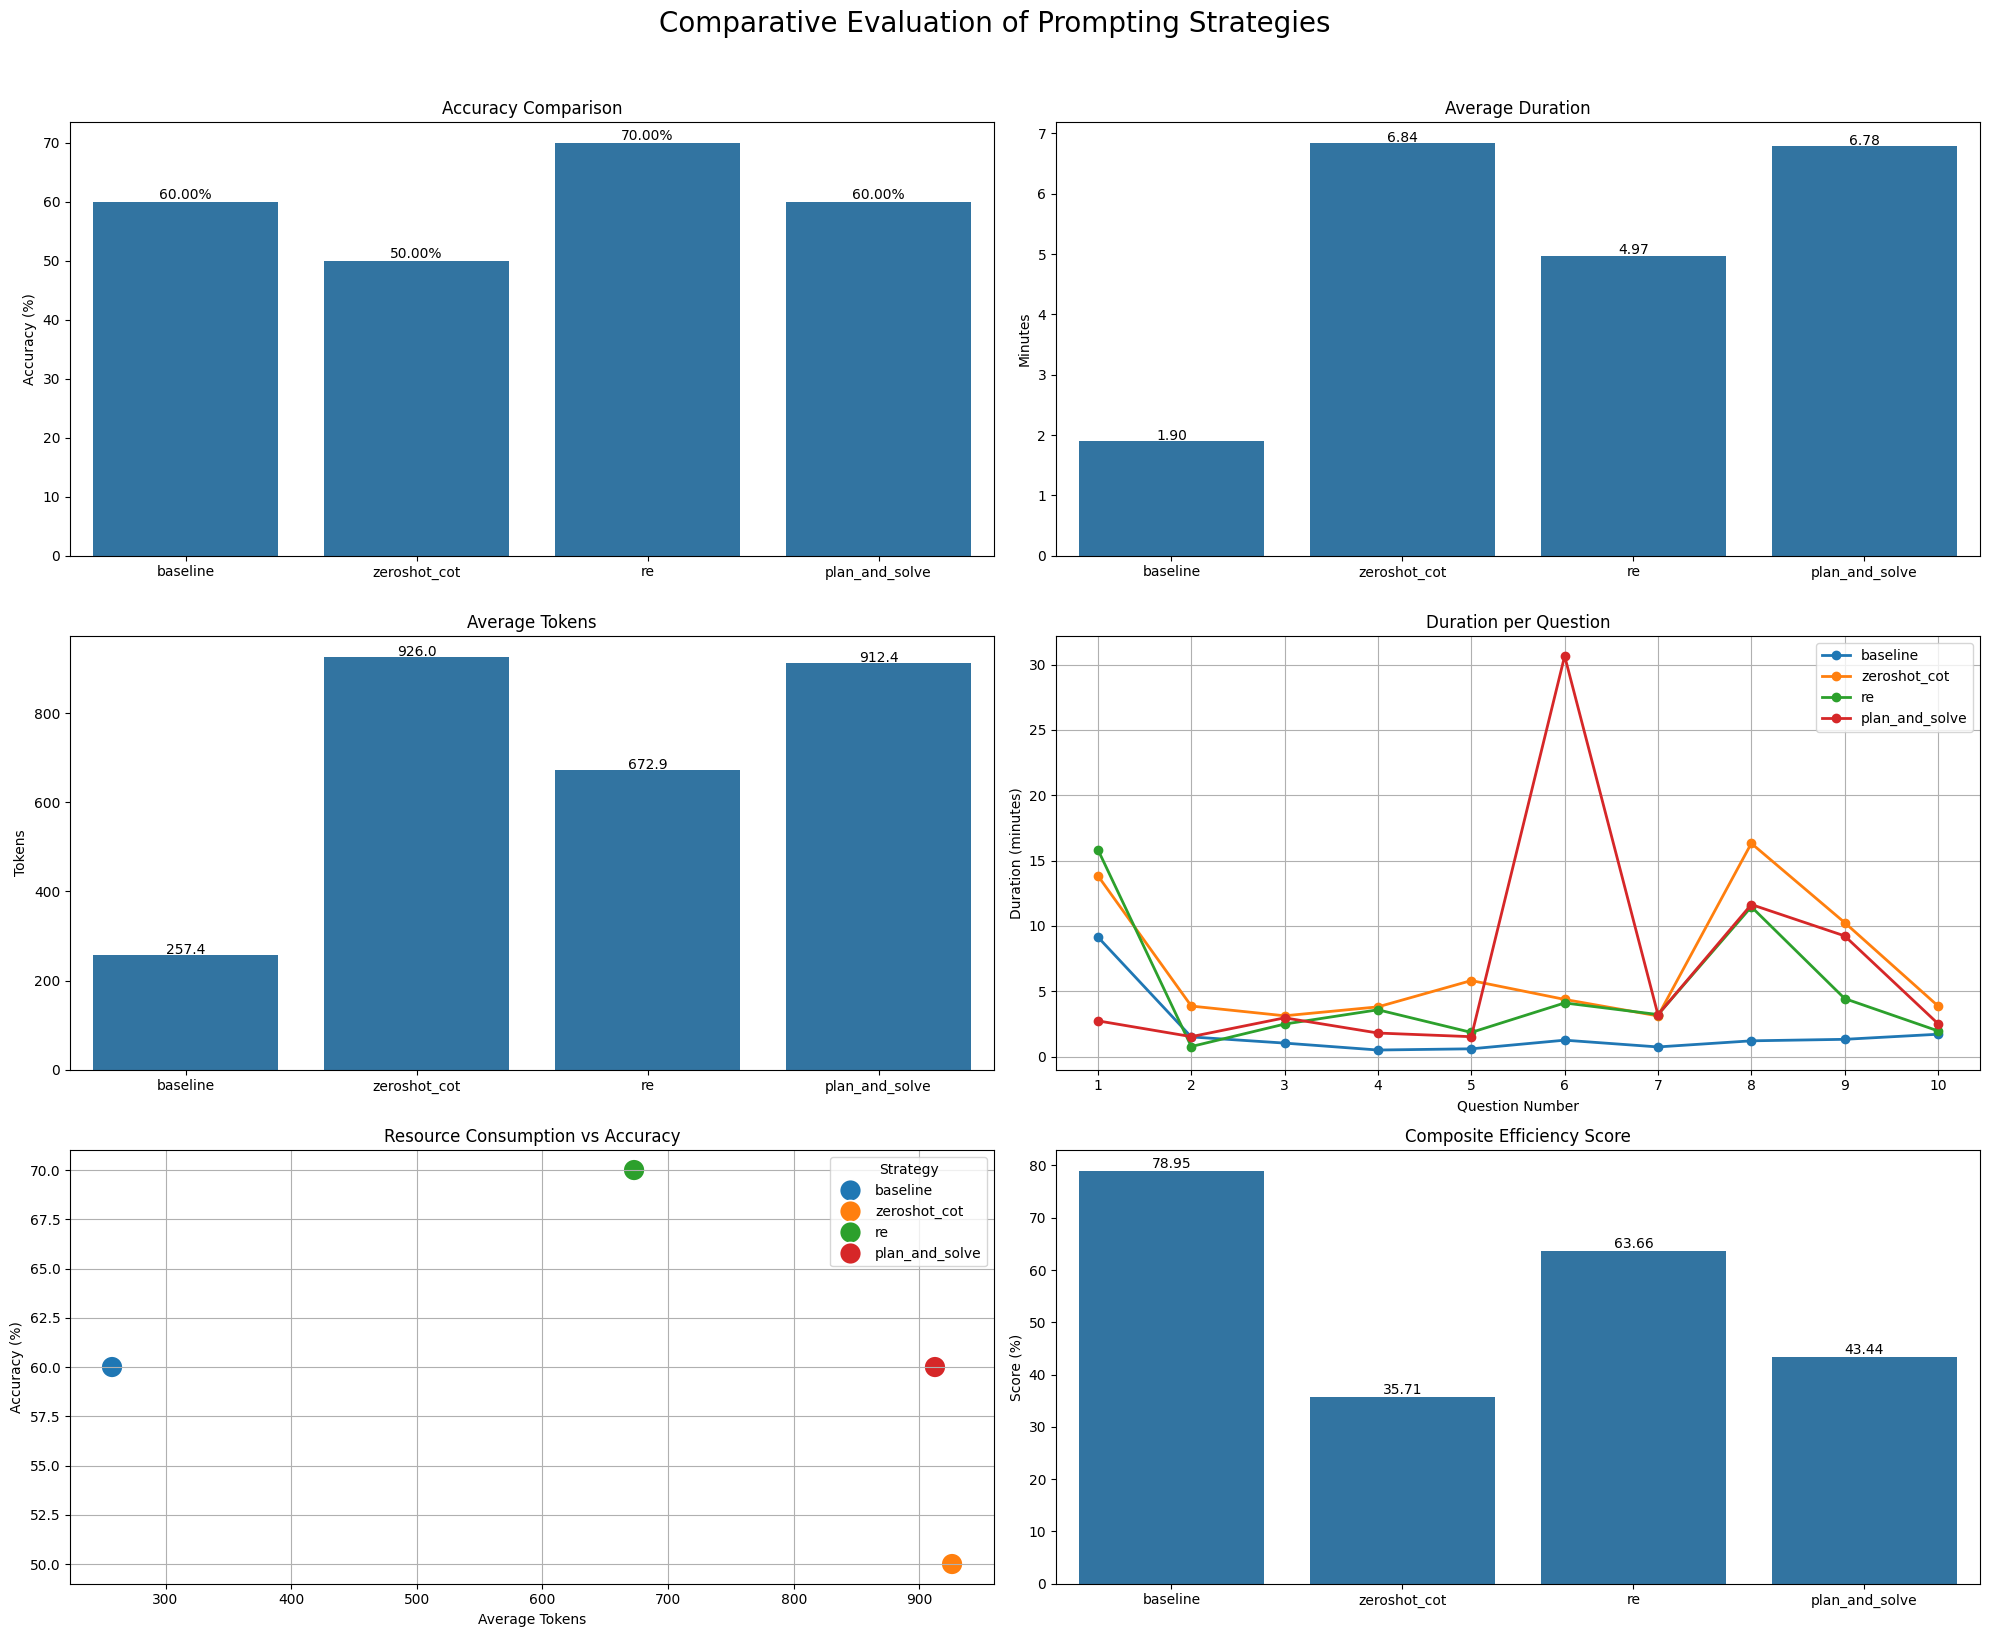

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(20, 16))

sns.barplot(
    data=metrics_df,
    x='Strategy',
    y='Accuracy',
    ax=axes[0, 0]
)

axes[0, 0].set_title("Accuracy Comparison")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].set_xlabel("")

for i, v in enumerate(metrics_df["Accuracy"]):
    axes[0, 0].text(i, v + 0.5, f"{v:.2f}%", ha='center')

sns.barplot(
    data=metrics_df,
    x='Strategy',
    y='Avg Duration',
    ax=axes[0, 1]
)

axes[0, 1].set_title("Average Duration")
axes[0, 1].set_ylabel("Minutes")
axes[0, 1].set_xlabel("")

for i, v in enumerate(metrics_df["Avg Duration"]):
    axes[0, 1].text(i, v + 0.02, f"{v:.2f}", ha='center')

sns.barplot(
    data=metrics_df,
    x='Strategy',
    y='Avg Tokens',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Average Tokens")
axes[1, 0].set_ylabel("Tokens")
axes[1, 0].set_xlabel("")

for i, v in enumerate(metrics_df["Avg Tokens"]):
    axes[1, 0].text(i, v + 2, f"{v:.1f}", ha='center')

for s in strategies:
    axes[1, 1].plot(
        question_numbers,
        df[f"{s}_duration"],
        marker='o',
        linewidth=2,
        label=s
    )

axes[1, 1].set_title("Duration per Question")
axes[1, 1].set_xlabel("Question Number")
axes[1, 1].set_ylabel("Duration (minutes)")
axes[1, 1].legend()
axes[1, 1].grid(True)

step = max(1, len(df) // 10)
axes[1, 1].set_xticks(question_numbers[::step])

sns.scatterplot(
    data=metrics_df,
    x='Avg Tokens',
    y='Accuracy',
    hue='Strategy',
    s=250,
    ax=axes[2, 0]
)
axes[2, 0].set_title("Resource Consumption vs Accuracy")
axes[2, 0].set_xlabel("Average Tokens")
axes[2, 0].set_ylabel("Accuracy (%)")
axes[2, 0].grid(True)

sns.barplot(
    data=metrics_df,
    x='Strategy',
    y='Efficiency Score',
    ax=axes[2, 1]
)

axes[2, 1].set_title("Composite Efficiency Score")
axes[2, 1].set_ylabel("Score (%)")
axes[2, 1].set_xlabel("")

for i, v in enumerate(metrics_df["Efficiency Score"]):
    axes[2, 1].text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.suptitle(
    "Comparative Evaluation of Prompting Strategies",
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.savefig('prompting_strategies_evaluation.png')
plt.show()